### Лабораторная работа 4. СМО (Система массового обслуживания)
Имеется n-канальная СМО с неограниченной очередью. На ее вход поступает простейший поток заявок с интенсивностью X; время обслуживания — показательное с параметром Х. Обслуживание происходит без гарантии качества; с вероятностью р оно удовлетворяет заявку, а с вероятностью q = 1 — р — не удовлетворяет, и заявка обращается в СМО вторично и либо сразу обслуживается, если нет очереди, либо становится в очередь, если она есть. Ввести состояния СМО (нумеруя их по числу заявок в СМО); найти финальные вероятности состояний и характеристики эффективности СМО. Найти среднее число рекламаций, поданных в единицу времени, если каждая неудачно обслуженная заявка подает рекламацию с вероятностью R.

Интенсивность: $\lambda$ = X  <br>
Время обслуживания - показательное распределение с параметром X. <br>$\mu$ = X, => среднее время обслуживания 1 / X

## Решение
$s_0$ - СМО свободна <br/>
$s_1$ - занят один канал <br/>
$s_k$ - занято k каналов (1 <= k <= n) <br/>
$s_n$ - заняты все n каналов <br/>
$s_{n+r}$ - заняты все n каналов, а r заявок стоит в очереди <br/>
Граф состояний приведен ниже
![](image_copy.png)
где интенсивность потока обслуживаний $\widetilde{\mu} = p\mu$ = pX <br/>
Тогда $\widetilde{p}$ = $\lambda$ / $\widetilde{\mu}$ = $\lambda$ / $p\mu$ = X / pX = 1 / p <br/>
Условие установления предельного стационарного режима: $\widetilde{p}$ <= n (выберем значение. n подходящим под данное условие)

##  Финальные вероятности состояний
Финальные вероятности состояний выражаются следующими формулами
![](final_probabilities.png)
p -> $\widetilde{p}$ = 1 / p <br/> $\chi$ = $\widetilde{p}$ / n = 1 / np

Показательное распределение (экспоненциальное распределение) описывает время между независимыми событиями, которые происходят с постоянной средней частотой (интенсивностью).

Пример. Пусть есть магазин, в который время от времени заходят покупатели. При определённых допущениях время между появлениями двух последовательных покупателей будет случайной величиной с экспоненциальным распределением. Среднее время ожидания нового покупателя (см. ниже) равно 1/λ
Сам параметр λ тогда может быть интерпретирован как среднее число новых покупателей за единицу времени.

### Найдем вероятности состояния системы:



In [15]:
import math

p = 0.7 #  вероятность успешного обслуживания заявки
n = 3 # количество обслуживающих каналов в системе массового обслуживания (СМО)
X = 3 # интенсивность поступления заявок (входящий поток)
Y = 1 # интенсивность обслуживания заявок (средняя скорость обслуживания)
p_tilde = X / (p* Y) # отношение интенсивности входящего потока к "эффективной" интенсивности обслуживания с учетом вероятности успешного обслуживания
chi = p_tilde / n # загрузка системы, отношение входящего потока к числу каналов

def p_0(p_tilde, chi, n):
    """
    Функция для вычисления вероятности того, что в системе нет заявок (состояние 0). Это базовая вероятность, от которой зависят остальные вероятности состояний СМО.
    """
    result = 1
    for i in range(1, n + 1):
        result += (p_tilde ** i / math.factorial(i))
    result += (p_tilde ** (n + 1) / (n * math.factorial(n))) * (1 / (1 - chi))
    return 1 / result
    
def p_k(p_tilde, k, p_0):
    """
    Функция для вычисления вероятности состояния, когда в системе находится k заявок, при условии, что их количество не превышает число каналов n.
    """
    return p_tilde ** k * p_0 / math.factorial(k)

def p_n_r(p_tilde, n, r, p_0):
    """
    Функция для вычисления вероятности того, что в системе больше заявок, чем доступных каналов (S > n). r — это количество заявок в очереди.
    """
    return p_tilde ** (n + r) * p_0 / (n ** r * math.factorial(n))
    

def calculate_probabilities(p_tilde, chi, n, size):
    """
    Основная функция для вычисления списка вероятностей для всех состояний от 0 до заданного размера size.
    """
    if(size < n):
        print('Размер должен быть > n')
        return
    p_list = []
    _p_0 = p_0(p_tilde, chi, n)
    p_list.append(_p_0)
    for k in range(1, n + 1):
        p_list.append(p_k(p_tilde, k, _p_0))
    for r in range(1, size - n + 1):
        p_list.append(p_n_r(p_tilde, n, r, _p_0))
    return p_list

Проверяем выполнение условия установления стационарного режима в системе массового обслуживания (СМО) и выводит вероятности состояний, если условие выполнено.
Здесь проверяется, что chi (загрузка системы) не превышает 1. Это важно, потому что если загрузка системы больше 1, система находится в нестабильном состоянии (число заявок в очереди бесконечно растет). Если chi <= 1, то система может работать в стационарном режиме.

In [16]:
size = 12
print(f'chi {chi}')
if chi <= 1:
    p_list = calculate_probabilities(p_tilde, chi, n, size)
    for i in range(size):
        print(f'p[{i}] :  {p_list[i]}')
    print(f'sum : {sum(p_list)}')
else:
    print('Условие установления предельного страционарного режима не выполнено')

chi 1.4285714285714286
Условие установления предельного страционарного режима не выполнено


##  Характеристики эффективности СМО

Среднее число ожидающих заявок
<br/>
![](moz.png)
<br/>
Среднее число заявок в системе
<br/>
![](m.png)

Вычисления различных характеристик эффективности работы системы массового обслуживания (СМО) с неограниченной очередью

In [17]:
def m_waiting(n, p_list):
    """
    Функция вычисляет среднее число заявок в очереди.
    """
    m = 0
    for i in range(n + 1, len(p_list)):
        m += i * p_list[i]
    return m
        
def m_all(n, p_list):
    """
    Эта функция вычисляет среднее число заявок в системе (включая и те, которые обслуживаются, и те, которые стоят в очереди).
    """
    m = 0
    for i in range(len(p_list)):
        m += i * p_list[i]
    return m

def mean_busy_channels(n, p_list):
    """
    Эта функция вычисляет среднее число занятых каналов.
    """
    m = 0
    for i in range(n + 1):
        m += i * p_list[i]
    for i in range(n + 1, len(p_list)):
        m += n * p_list[i]
    return m

def mean_free_channels(n, p_list):
    """
    Эта функция вычисляет среднее число свободных каналов как разность общего числа каналов и среднего числа занятых каналов.
    """
    return n - mean_busy_channels(n, p_list)

print('Вероятность отказа: P(отк) = 0, т.к. неограниченная очередь')
print('Среднее число заявок в очереди: ', m_waiting(n, p_list))
print('Среднее число заявок в системе: ', m_all(n, p_list))
print('Среднее число заявок в обслуживании : ', m_all(n, p_list) - m_waiting(n, p_list))
print()
print('Среднее число занятых каналов: ', mean_busy_channels(n, p_list))
print('Среднее число свободных каналов: ', mean_free_channels(n, p_list))
print('Коэффициент загрузки: ', mean_busy_channels(n, p_list) / n)
print('Коэффициент простоя: ', mean_free_channels(n, p_list) / n)

Вероятность отказа: P(отк) = 0, т.к. неограниченная очередь
Среднее число заявок в очереди:  3.915869940016935
Среднее число заявок в системе:  4.655729113843343
Среднее число заявок в обслуживании :  0.739859173826408

Среднее число занятых каналов:  2.6500951107400654
Среднее число свободных каналов:  0.34990488925993457
Коэффициент загрузки:  0.8833650369133551
Коэффициент простоя:  0.11663496308664485


#### Среднее время ожидания в системе

In [18]:
mean_t = 1 / X # среднее время обслуживания заявки
print('Среднее время обслуживания заявки: ', mean_t)
print('Среднее время нахождения в очереди: ', mean_t * m_waiting(n, p_list))
print('Среднее время нахождения в системе: ', mean_t + mean_t * m_waiting(n, p_list))

Среднее время обслуживания заявки:  0.3333333333333333
Среднее время нахождения в очереди:  1.3052899800056448
Среднее время нахождения в системе:  1.638623313338978


##  Среднее число рекламаций

In [19]:
complaint_rate = 0.3 # вероятность подачи рекламации после неудачного обслуживания
mean_current_claims = m_all(n, p_list) - m_waiting(n, p_list)
mean_complaint_number = mean_current_claims * (1 - p) * complaint_rate
print('Среднее число рекламаций за единицу времени: ', mean_complaint_number)

Среднее число рекламаций за единицу времени:  0.06658732564437672


##  Моделирование СМО

In [20]:
import random
import numpy as np

# Класс Claim представляет заявку в системе
class Claim:
    def __init__(self):
        self.time_in_system = 0       # Время, проведённое в системе
        self.time_in_queue = 0        # Время, проведённое в очереди
        self.time_in_processing = 0   # Время, проведённое на обработке
        self.complaint_number = 0     # Количество поданных рекламаций

# Класс Channel представляет канал обслуживания в системе
class Channel:
    def __init__(self):
        self.is_free = True                   # Свободен ли канал
        self.time_to_solve_remaining = 0      # Оставшееся время для завершения обработки заявки

# Генератор системы массового обслуживания (СМО)
class QueuingSystemGenerator: 
    def __init__(self, n, probability, X, Y, R, size_of_probabilities):
        self.probability = probability        # Вероятность успешного обслуживания заявки
        self.n = n                            # Количество каналов
        self.channels = [Channel() for i in range(n)]  # Список каналов
        self.claims = []                      # Очередь заявок
        self.X = X                            # Интенсивность входящего потока (параметр Пуассона)
        self.Y = Y                            # Интенсивность обслуживания (параметр экспоненциального распределения)
        self.time_discreteness = 100          # Частота дискретизации времени
        self.time_step = 1 / self.time_discreteness  # Шаг времени
        self.processedClaims = []             # Список обработанных заявок
        self.complaint_prob = R               # Вероятность подачи рекламации
        self.size_of_probabilities = size_of_probabilities # Размер массива для хранения вероятностей занятости каналов
        self.channel_probabilities = [0 for i in range(size_of_probabilities)]  # Вероятности занятости каналов
    
    # Определяет, была ли заявка обслужена успешно
    def rand_is_claim_accepted(self):
        return random.random() < self.probability
    
    # Генерирует случайное время обслуживания заявки
    def rand_claim_resolve_time(self):
        return np.random.exponential(1 / self.Y)
    
    # Определяет, поступила ли новая заявка в текущем шаге времени
    def rand_new_claim_comming(self):
        return random.random() < self.X / self.time_discreteness
    
    # Определяет, подана ли рекламация на неудачное обслуживание
    def rand_is_complaint(self):
        return random.random() < self.complaint_prob
    
    # Возвращает количество занятых каналов в системе
    def busy_channels_count(self):
        count = 0
        for i in range(len(self.channels)):
            if not self.channels[i].is_free:
                count += 1
        return count
    
    # Моделирует процесс поступления заявок
    def simulate_coming_claims(self):
        has_come = self.rand_new_claim_comming()
        if has_come:
            self.claims.append(Claim())  # Если заявка поступила, добавляем её в очередь
    
    # Моделирует перемещение заявок из очереди на свободные каналы
    def simulate_claim_to_free_channels(self):
        for i in range(len(self.channels)):
            if self.channels[i].is_free:
                if len(self.claims) == 0:
                    break
                # Перемещаем заявку с начала очереди в канал
                self.channels[i].solving_claim = self.claims.pop()
                self.channels[i].is_free = False
                # Генерируем случайное время для завершения обслуживания
                self.channels[i].time_to_solve_remaining += self.rand_claim_resolve_time()

    # Моделирует процесс обслуживания заявок
    def simulate_process_claims(self):
        # Увеличиваем время пребывания заявок в очереди
        for i in range(len(self.claims)):
            self.claims[i].time_in_queue += self.time_step
        
        # Обрабатываем заявки в каналах
        for i in range(len(self.channels)):
            if not self.channels[i].is_free:
                claim = self.channels[i].solving_claim
                if self.channels[i].time_to_solve_remaining > 0:
                    # Продолжаем обслуживание заявки
                    self.channels[i].time_to_solve_remaining -= self.time_step
                    claim.time_in_processing += self.time_step
                else:
                    # Завершение обслуживания заявки
                    self.channels[i].is_free = True
                    self.channels[i].time_to_solve_remaining = 0
                    is_claim_accepted = self.rand_is_claim_accepted()
                    if is_claim_accepted:
                        # Если заявка успешно обслужена, добавляем её в список завершенных
                        self.processedClaims.append(claim)
                    else:
                        # Если заявка не была успешно обслужена, возвращаем её в очередь
                        self.claims.append(claim)
                        # Проверяем, подана ли рекламация
                        if self.rand_is_complaint():
                            claim.complaint_number += 1
    
    # Выполняет шаг симуляции времени
    def next_time_step(self):
        # 1. Моделируем поступление новых заявок
        self.simulate_coming_claims()
        # 2. Перемещаем заявки из очереди на свободные каналы
        self.simulate_claim_to_free_channels()
        # 3. Обрабатываем заявки в каналах
        self.simulate_process_claims()
    
    # Выполняет симуляцию на протяжении указанного количества временных единиц
    def run_simulation(self, time_units):
        avg_busy_channels = 0  # Среднее количество занятых каналов
        for i in range(time_units * self.time_discreteness):
            self.next_time_step()  # Выполняем шаг симуляции
            busy_channels = self.busy_channels_count()  # Подсчитываем количество занятых каналов
            avg_busy_channels = (avg_busy_channels * i + busy_channels) / (i + 1)  # Обновляем среднее количество занятых каналов
            
            if busy_channels == self.n:
                # Если все каналы заняты, считаем заявки в очереди
                claims_in_queue = len(self.claims)
                busy_channels += claims_in_queue
            if busy_channels < self.size_of_probabilities:
                # Увеличиваем счётчик занятости каналов для соответствующего количества занятых каналов
                self.channel_probabilities[busy_channels] += 1
        
        print('Среднее количество занятых каналов: ', avg_busy_channels)
        # Нормализуем вероятности по количеству временных шагов
        self.channel_probabilities = [self.channel_probabilities[i] / (time_units * self.time_discreteness) for i in range(len(self.channel_probabilities))]
        return self.channel_probabilities

In [21]:
R = 0.3 # Вероятность того, что неудачно обслуженная заявка подаст рекламацию 
size_of_probabilities = 13 # Максимальный размер массива вероятностей, который используется для хранения вероятностей различных состояний каналов (занятость каналов от 0 до 12)

generator = QueuingSystemGenerator(n, p, X, Y, R, size_of_probabilities)
channel_probabilities = generator.run_simulation(1000)

Среднее количество занятых каналов:  2.9694400000000223


### Сравнение аналитических результатов и симуляции

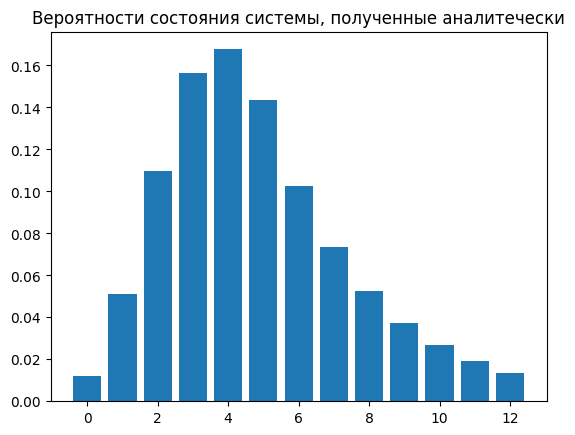

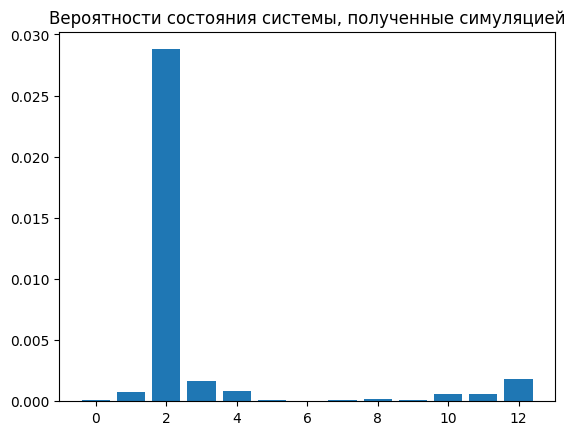

[0.0001, 0.00074, 0.02878, 0.00162, 0.00084, 9e-05, 2e-05, 9e-05, 0.00015, 0.00011, 0.00056, 0.00063, 0.00179]


In [22]:
import matplotlib.pyplot as plt

plt.bar(range(len(p_list)), p_list)
plt.title('Вероятности состояния системы, полученные аналитечески')
plt.show()

plt.bar(range(len(channel_probabilities)), channel_probabilities)
plt.title('Вероятности состояния системы, полученные симуляцией')
plt.show()
print(channel_probabilities)